In [22]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [23]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int


In [24]:
def greeter_node(state: AgentState) -> AgentState:
    """Greeter node which says hi to the person"""  
    state["name"] = f"Hi there, {state['name']}"
    state["counter"] = 0
    return state

In [25]:
def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""    
    state["number"].append(random.randint(0,10))
    state["counter"] += 1
    return state

In [26]:
def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""    
    if state["counter"] < 5:
        print("ENTERING LOOP",state["counter"])
        return "loop"
    else:
        return "exit"

In [27]:
graph = StateGraph(AgentState)

graph.add_node("greeter",greeter_node)
graph.add_node("random",random_node)
graph.add_edge("greeter","random")

graph.set_entry_point("greeter")
graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)

app = graph.compile()

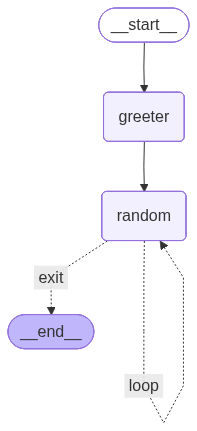

In [28]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
app.invoke({"name": "John", "number": [], "counter": -100})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, John', 'number': [9, 9, 1, 3, 9], 'counter': 5}